# Weather Prediction

This script focuses on how to implement weather prediction on our hydrogen prediction script.

### OpenWeatherMap API:

Error: 401, {"cod":401, "message": "Invalid API key. Please see https://openweathermap.org/faq#error401 for more info."}
Variable 'TemperatureForecast' not found!


UnboundLocalError: cannot access local variable 'data' where it is not associated with a value

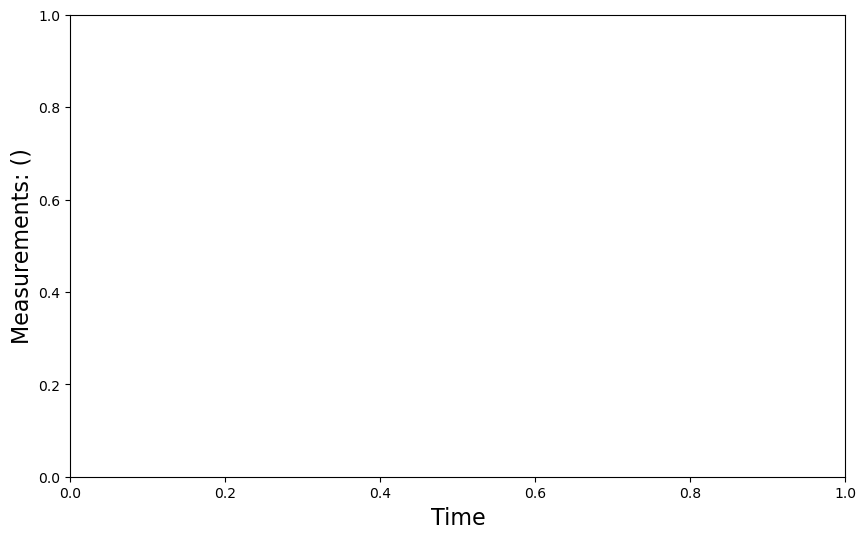

In [10]:
#OpenWeatherMap:

import requests
import pandas as pd
import numpy as np
import requests
import json
import datetime
import matplotlib.pyplot as plt
from datetime import datetime

API_KEY = "1f29f342f77bce9af80c75c3e6bc0945" # my API from openweathermap

lat = 51.9965298 # GV location
lon = 4.3775611 # GV location
city = 'Delft'


url = f"https://api.openweathermap.org/data/2.5/solar_radiation?lat={lat}&lon={lon}&appid={API_KEY}"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()

    for hourly in data['hourly']:
        # Parse timestamp
        timestamp = datetime.fromtimestamp(hourly['dt'])
        temperature = hourly['temp']
        times.append(timestamp)
        temperatures.append(temperature)

    # Create a DataFrame to store the temperature
    TemperatureForecast = pd.DataFrame({
        "time": times,
        "Temperature (°C)": temperatures,
        "value_float": temperatures,
        "device_id": "forecast",
        "measurement_id": "temperature",
        "application_id": "forecast",
        "name": "Seasonal storage system"
    })
else:
    print(f"Error: {response.status_code}, {response.text}")

fplot('TemperatureForecast')


### SolCast API

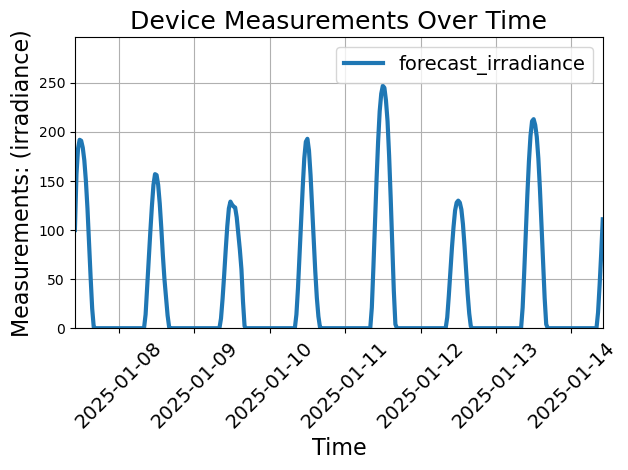

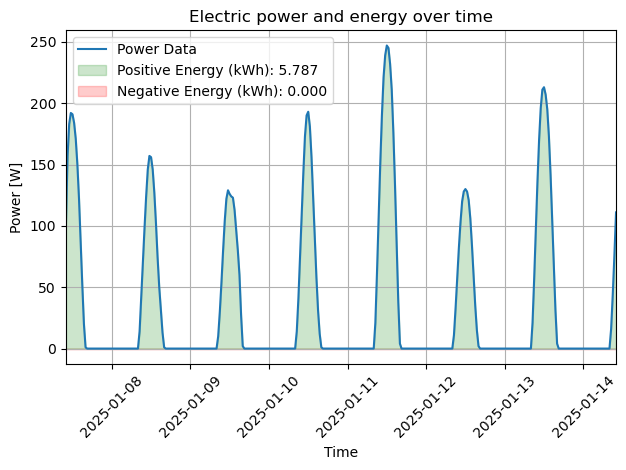

(5.78725, 5.78725, 0.0)

In [8]:
# With Solcast data: (6 months free)

API_KEY = "nhppB-d7EVaGNdzCT14pTFwKM5QVpeJ3" # My solcast API Key

latitude = 51.9965298 # GV Location
longitude = 4.3775611 # GV Location


# Solcast API URL for estimated solar irradiance data
url = "https://api.solcast.com.au/weather_sites/4996-f45e-9e61-e8e2/forecasts?format=json"
payload={}
headers = {
    "Authorization": f"Bearer {API_KEY}" # Give my key to solcast
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    data = response.json()
    
    times = []
    irradiance_values = []
    
    if 'forecasts' in data:  # Only get forecast
        for forecast in data['forecasts']:
            timestamp = forecast['period_end'] # Extract the timestamp and solar irradiance
            irradiance = forecast['ghi']
            
            timestamp = timestamp[:26] + timestamp[29:]  # Need time conversion BC wouldnt work otherwise
            time = datetime.strptime(timestamp, "%Y-%m-%dT%H:%M:%S.%f")  # Remove Z BC Wouldnt work otherwise
            times.append(time)
            irradiance_values.append(irradiance)

        forecast_irradiance = pd.DataFrame({ # Make a DF that works with my scripts
        'time': times,
        'value_float': irradiance_values,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })
        
        
        

    else:
        print("No forecast data found in the response.")
else:
    print(f"Error: Unable to fetch data, status code {response.status_code}")
    print(f"Response content: {response.text}")  

fplot('forecast_irradiance') # Show the graph
integrate_hr('forecast_irradiance') # Amount of total availble power 

### WeatherAPI:

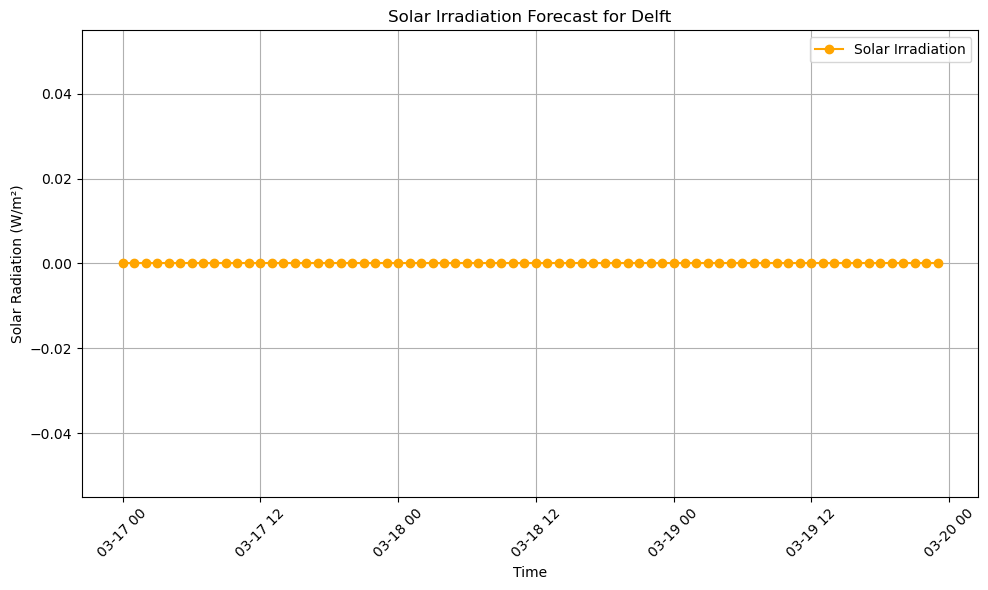

In [4]:

import requests
import json
import matplotlib.pyplot as plt
from datetime import datetime

# Replace with your WeatherAPI.com API key
API_KEY = "46887980f5344afc932105345240412"

# Define location and API endpoint
location = "Delft"  # City or coordinates (latitude,longitude)
base_url = f"http://api.weatherapi.com/v1/forecast.json"

# Parameters for the API request
params = {
    "key": API_KEY,
    "q": location,
    "days": 14,  # Forecast for the next 3 days
    "aqi": "no",  # Air quality data not needed
    "alerts": "no"  # Weather alerts not needed
}

# Fetch the data
response = requests.get(base_url, params=params)

# Check for a successful response
if response.status_code == 200:
    data = response.json()
    
    # Extract forecast data
    forecast_days = data.get("forecast", {}).get("forecastday", [])
    
    # Prepare lists for timestamps and solar radiation values
    times = []
    solar_irradiance = []
    
    for day in forecast_days:
        for hour_data in day.get("hour", []):
            # Parse the time and solar radiation data
            timestamp = hour_data["time"]
            radiation = hour_data.get("solarradiation", 0)  # Solar radiation in W/m²
            
            # Append to lists
            times.append(datetime.strptime(timestamp, "%Y-%m-%d %H:%M"))
            solar_irradiance.append(radiation)
    
    # Plot the data
    plt.figure(figsize=(10, 6))
    plt.plot(times, solar_irradiance, label="Solar Irradiation", color="orange", marker="o")
    plt.title(f"Solar Irradiation Forecast for {location}")
    plt.xlabel("Time")
    plt.ylabel("Solar Radiation (W/m²)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()
else:
    print(f"Error fetching data: {response.status_code}")
    print(response.text)

### meteomatics's API trial:

In [6]:
import datetime as dt
import meteomatics.api as api

username = 'tudelft_schat_daan'
password = 'J2x5wXBjz7'

coordinates = [(51.9965298, 4.3775611)]
parameters = ['t_2m:C', 'global_rad:W', 'wind_speed_10m:ms']
model = 'mix'
startdate = dt.datetime.now(dt.timezone.utc).replace(minute=0, second=0, microsecond=0)
enddate = startdate + dt.timedelta(days=7)
interval = dt.timedelta(hours=1)


df = api.query_time_series(coordinates, startdate, enddate, interval, parameters, username, password, model=model)
df = df.reset_index()


df = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(df['validdate']),  # Converts to datetime objectdf['validdate'],
        'value_float': df['global_rad:W'],
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })

fplot('df')

Unauthorized: Account expired. Please check https://api.meteomatics.com/user_stats for more detail, or contact api@meteomatics.com.

### OpenMeteo API

Coordinates 51.987998962402344°N 4.378999710083008°E
Elevation 0.0 m asl
Timezone b'Europe/Amsterdam' b'GMT+1'
Timezone difference to GMT+0 3600 s


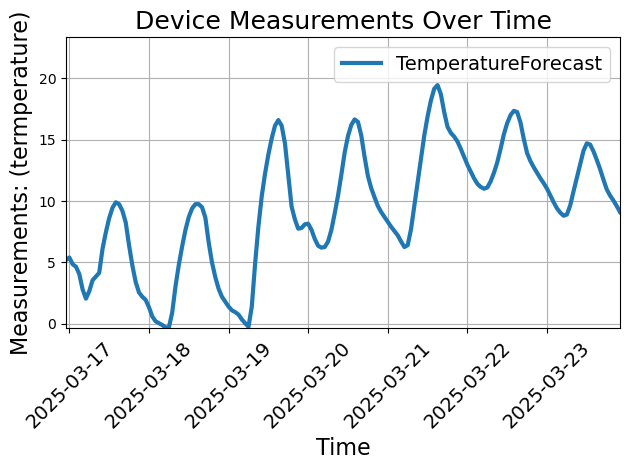

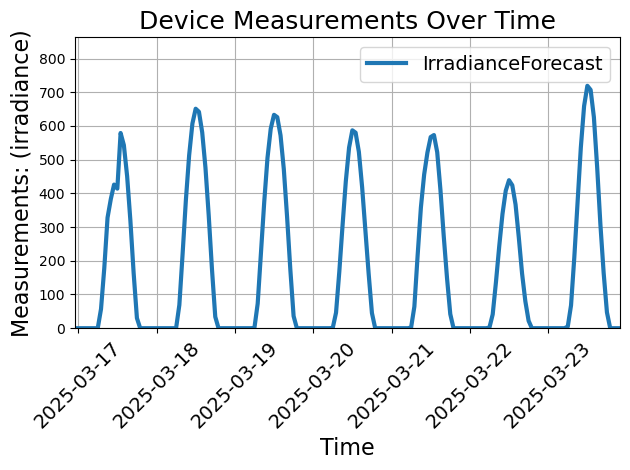

In [12]:
# OpenMeteo API: (their code)
# https://open-meteo.com/en/docs#latitude=51.9965298&longitude=4.3775611&hourly=temperature_2m,shortwave_radiation&timezone=auto&forecast_days=3

import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://api.open-meteo.com/v1/forecast"
params = {
	"latitude": 51.9965298,
	"longitude": 4.3775611,
	"hourly": ["temperature_2m", "shortwave_radiation"],
	"timezone": "auto",
	"forecast_days": 7
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_shortwave_radiation = hourly.Variables(1).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

TemperatureForecast = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

IrradianceForecast = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_shortwave_radiation,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })


fplot('TemperatureForecast')
fplot('IrradianceForecast')

Coordinates 52.00600051879883°N 4.349999904632568°E
Elevation 4.0 m asl
Timezone b'Europe/Amsterdam' b'GMT+1'
Timezone difference to GMT+0 3600 s
                         date  temperature_2m  global_tilted_irradiance
0   2024-08-03 23:00:00+00:00       19.750000                       0.0
1   2024-08-03 23:15:00+00:00       19.500000                       0.0
2   2024-08-03 23:30:00+00:00       19.200001                       0.0
3   2024-08-03 23:45:00+00:00       18.850000                       0.0
4   2024-08-04 00:00:00+00:00       18.650000                       0.0
..                        ...             ...                       ...
763 2024-08-11 21:45:00+00:00       21.549999                       0.0
764 2024-08-11 22:00:00+00:00       21.400000                       0.0
765 2024-08-11 22:15:00+00:00       21.250000                       0.0
766 2024-08-11 22:30:00+00:00       21.100000                       0.0
767 2024-08-11 22:45:00+00:00       20.950001                 

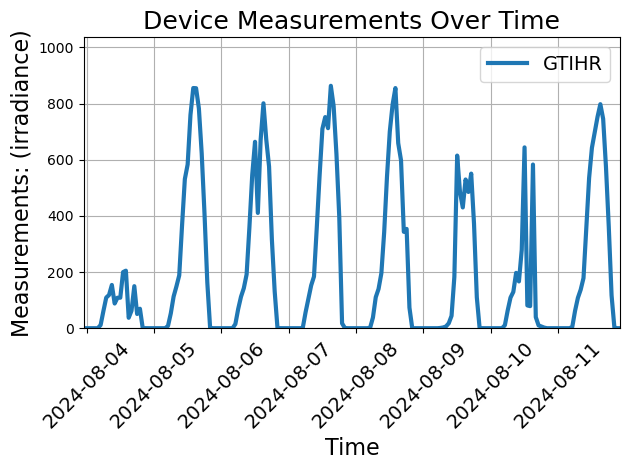

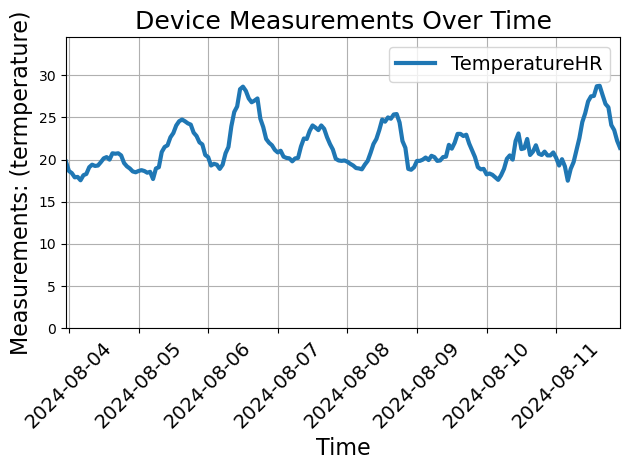

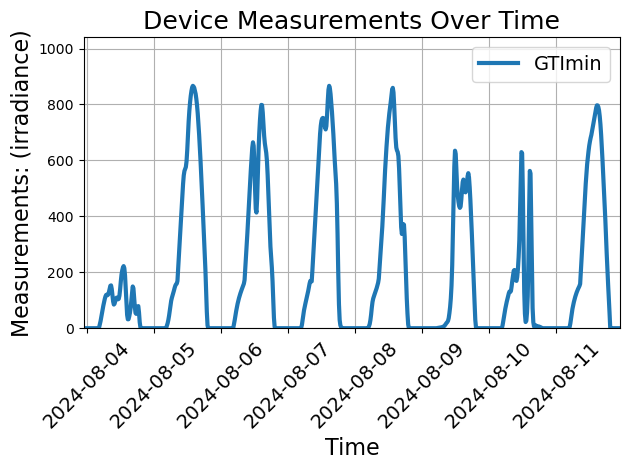

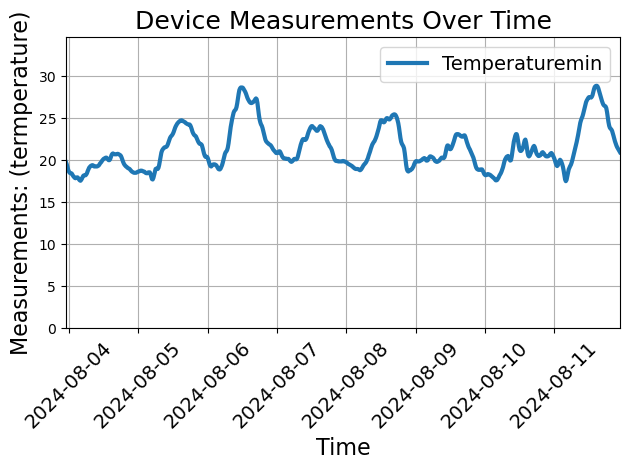

In [14]:
# Openmeteo historical data:
import openmeteo_requests

import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.00667,
	"longitude": 4.35556,
	"start_date": "2024-08-04",
	"end_date": "2024-08-11",
	"minutely_15": ["temperature_2m", "global_tilted_irradiance"],
	"hourly": ["temperature_2m", "global_tilted_irradiance"],
	"timezone": "auto",
	"tilt": 45,
	"azimuth": 67
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_global_tilted_irradiance = minutely_15.Variables(1).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end = pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}
minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["global_tilted_irradiance"] = minutely_15_global_tilted_irradiance

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print(minutely_15_dataframe)

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_global_tilted_irradiance = hourly.Variables(1).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}
hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["global_tilted_irradiance"] = hourly_global_tilted_irradiance


TemperatureHR = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

GTIHR = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_global_tilted_irradiance,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })


Temperaturemin = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(minutely_15_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': minutely_15_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

GTImin = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(minutely_15_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': minutely_15_global_tilted_irradiance,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })



fplot('GTIHR')
fplot('TemperatureHR')

fplot('GTImin')
fplot('Temperaturemin')

In [27]:
# Some functions:
# Setting up plotting layout
figdim = (10, 6)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

def fplotGTI(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = "GTI [W/m2]"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=device_measurement_label, color = 'darkorange')
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel("Global Tilted Radiation [W/m2]")
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Open-meteo GTI historical data for 2024',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_h2(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
    else:
        print(f"Variable '{var}' not found!")  
    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.title('Hydrogen production over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return H2Prod

Coordinates 52.00600051879883°N 4.349999904632568°E
Elevation 4.0 m asl
Timezone b'Europe/Amsterdam' b'GMT+1'
Timezone difference to GMT+0 3600 s
                           date  temperature_2m  global_tilted_irradiance
0     2023-12-31 23:00:00+00:00            8.30                       0.0
1     2023-12-31 23:15:00+00:00            8.25                       0.0
2     2023-12-31 23:30:00+00:00            8.15                       0.0
3     2023-12-31 23:45:00+00:00            8.10                       0.0
4     2024-01-01 00:00:00+00:00            7.30                       0.0
...                         ...             ...                       ...
35131 2024-12-31 21:45:00+00:00            6.65                       0.0
35132 2024-12-31 22:00:00+00:00            6.80                       0.0
35133 2024-12-31 22:15:00+00:00            6.90                       0.0
35134 2024-12-31 22:30:00+00:00            7.05                       0.0
35135 2024-12-31 22:45:00+00:00         

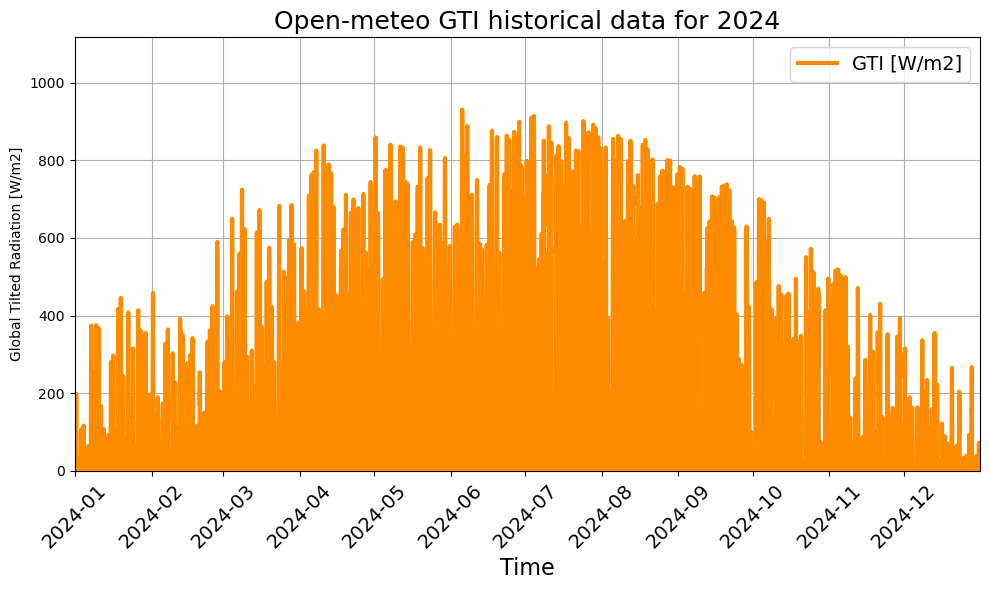

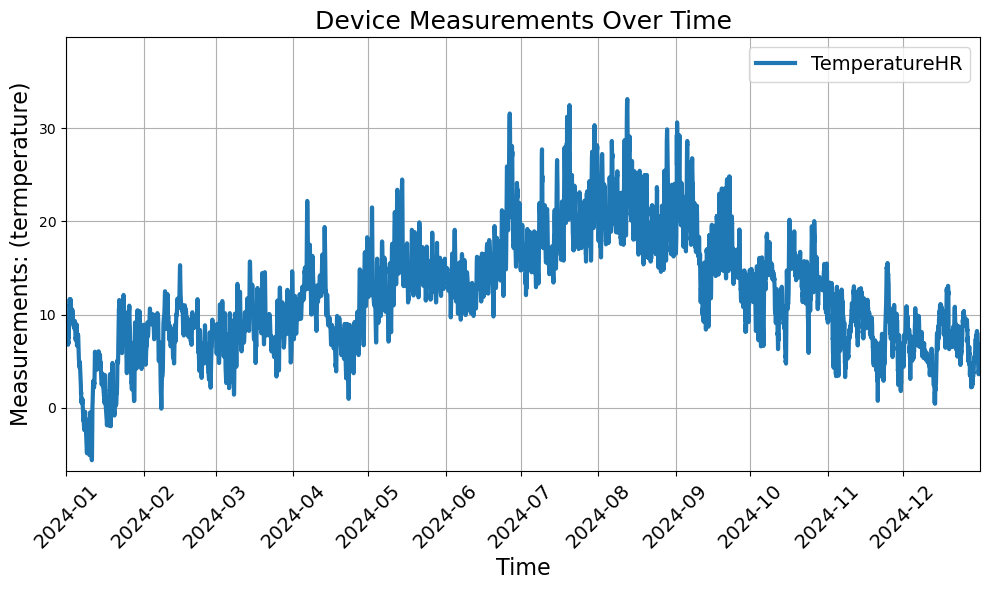

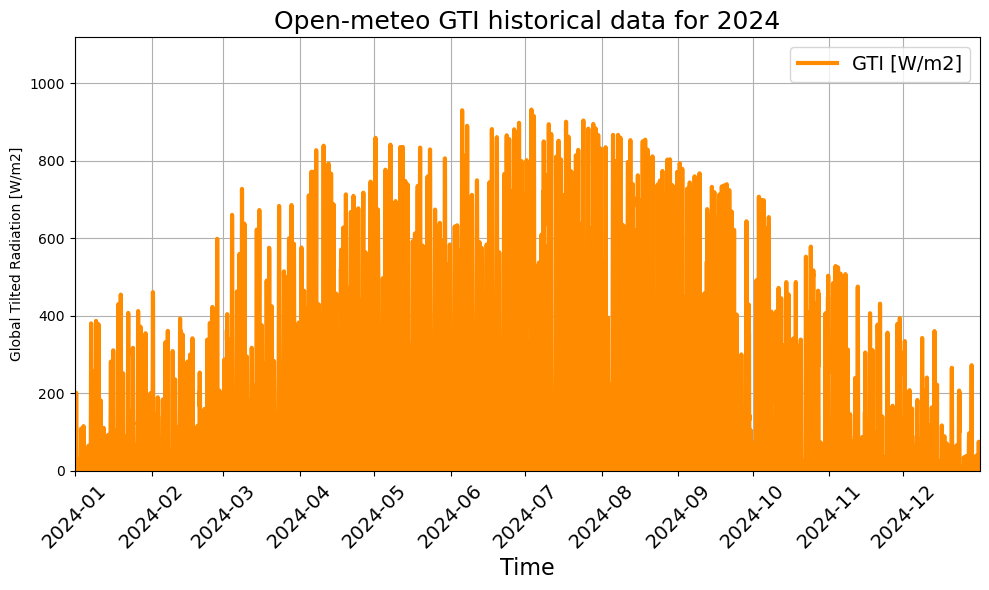

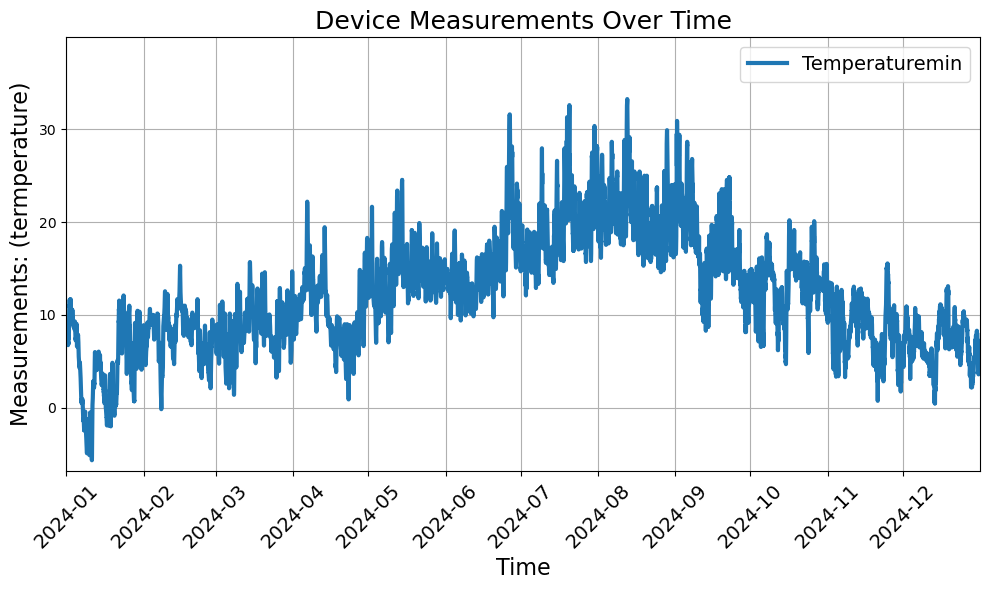

In [29]:
# Get solar data for 2024:

# Openmeteo historical data:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 52.00667,
	"longitude": 4.35556,
	"start_date": "2024-01-01",
	"end_date": "2024-12-31",
	"minutely_15": ["temperature_2m", "global_tilted_irradiance"],
	"hourly": ["temperature_2m", "global_tilted_irradiance"],
	"timezone": "auto",
	"tilt": 45,
	"azimuth": 67
}
responses = openmeteo.weather_api(url, params=params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation {response.Elevation()} m asl")
print(f"Timezone {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0 {response.UtcOffsetSeconds()} s")

# Process minutely_15 data. The order of variables needs to be the same as requested.
minutely_15 = response.Minutely15()
minutely_15_temperature_2m = minutely_15.Variables(0).ValuesAsNumpy()
minutely_15_global_tilted_irradiance = minutely_15.Variables(1).ValuesAsNumpy()

minutely_15_data = {"date": pd.date_range(
	start = pd.to_datetime(minutely_15.Time(), unit = "s", utc = True),
	end = pd.to_datetime(minutely_15.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = minutely_15.Interval()),
	inclusive = "left"
)}
minutely_15_data["temperature_2m"] = minutely_15_temperature_2m
minutely_15_data["global_tilted_irradiance"] = minutely_15_global_tilted_irradiance

minutely_15_dataframe = pd.DataFrame(data = minutely_15_data)
print(minutely_15_dataframe)

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_global_tilted_irradiance = hourly.Variables(1).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}
hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["global_tilted_irradiance"] = hourly_global_tilted_irradiance


TemperatureHR = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

GTIHR = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(hourly_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': hourly_global_tilted_irradiance,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })


Temperaturemin = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(minutely_15_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': minutely_15_temperature_2m,
        'device_id': 'forecaster',
        'measurement_id': 'termperature'
        })

GTImin = pd.DataFrame({ # Make a DF that works with my scripts
        'time': pd.to_datetime(minutely_15_data['date']),  # Converts to datetime objectdf['validdate'],
        'value_float': minutely_15_global_tilted_irradiance,
        'device_id': 'forecaster',
        'measurement_id': 'irradiance'
        })



fplotGTI('GTIHR')
fplot('TemperatureHR')

fplotGTI('GTImin')
fplot('Temperaturemin')

In [ ]:
import pandas as pd
from scipy.io import savemat

# Assuming GTImin is your dataframe
GTImin['time'] = pd.to_datetime(GTImin['time'])  # Ensure 'time' is in datetime format

# Set 'time' column as the index if needed (optional)
GTImin.set_index('time', inplace=True)

# If you want to resample or interpolate data (optional step)
# For example, resampling to 1-minute intervals and linear interpolation
GTImin_resampled = GTImin.resample('1S').interpolate(method='linear')

# Reset the index if you want 'time' to be a column again
GTImin_resampled = GTImin_resampled.reset_index()

# Save to .mat for MATLAB
savemat("GTIsec.mat", {"time": GTImin_resampled['time'].tolist(), "value_float": GTImin_resampled['value_float'].tolist()})

/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_12939/1086538189.py:12: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  GTImin_resampled = GTImin.resample('1S').interpolate(method='linear')
/var/folders/94/x7pykd1529z75np_t1jtxpzh0000gn/T/ipykernel_12939/1086538189.py:12: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  GTImin_resampled = GTImin.resample('1S').interpolate(method='linear')


In [31]:
import pandas as pd
from scipy.io import savemat

# Assuming GTImin is your dataframe
GTImin['time'] = pd.to_datetime(GTImin['time'])  # Ensure 'time' is in datetime format

# Set 'time' column as the index if needed (optional)
GTImin.set_index('time', inplace=True)

# If you want to resample or interpolate data (optional step)
# For example, resampling to 1-minute intervals and linear interpolation
GTImin_resampled = GTImin.resample('1T').interpolate(method='linear')

# Reset the index if you want 'time' to be a column again
GTImin_resampled = GTImin_resampled.reset_index()

# Save to .mat for MATLAB
savemat("GTImin.mat", {"time": GTImin_resampled['time'].tolist(), "value_float": GTImin_resampled['value_float'].tolist()})

KeyError: 'time'